In [84]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks, backtest_grid_search, plot_equities, max_drawdown, max_losing_streak, plot_conjunto, load_bt_csv
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [85]:
start = "2026-03-27"
# start = "2026-01-20"
end   = "2026-06-01"

In [86]:
symbols = load_symbols()
cfg = load_config()

In [87]:
ASSET = symbols[12]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [88]:
best = pd.read_json(f"{MODELS_DIR}/best_per_asset.json")

In [89]:
best

,CL,ES,GC,MFXI,NG,NQ,YM,ZB,ZN,ZS
strat,df_long,df_long,df_long,df_ops_strong,df_long_strong,df_long,df_ops_strong,df_ops_strong,df_ops,df_ops_strong
backtest,scalein_sizing,sizing,sizing,sizing,sizing,sizing,scalein_sizing,sizing,sizing,scalein
calmar,8.2257,-0.1219,1.0427,0.3551,0.188,-0.1673,0.2288,1.2188,0.8609,6.2328
sharpe,1.6833,-0.374,0.8643,0.4044,0.1657,-0.5267,0.3576,0.6243,0.8552,1.4829
max_dd,0.0312,0.1515,0.0327,0.0389,0.006,0.1096,0.0549,0.0123,0.0488,0.4148
cagr,0.2569,-0.0185,0.034,0.0138,0.0011,-0.0183,0.0126,0.015,0.042,2.5851
equity_final,506350.0,335276.9546,485851.982,5091.4967,70180.8087,622842.5448,205835.0,51741.2361,32986.8392,501375.0
pnl_final,206350.0,-14723.0454,35851.982,91.4967,180.8087,-27157.4552,5835.0,1741.2361,2986.8392,451375.0
equity_path,E:\Futuro\MLAlgoTrading\TradingBots\Models/cl/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/es/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/mfx...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ng/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/nq/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ym/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zb/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/...
trades_path,E:\Futuro\MLAlgoTrading\TradingBots\Models/cl/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/es/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/mfx...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ng/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/nq/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ym/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zb/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/...


In [90]:
best.columns

Index(['CL', 'ES', 'GC', 'MFXI', 'NG', 'NQ', 'YM', 'ZB', 'ZN', 'ZS'], dtype='str')

In [91]:
# dfs = {}
# for asset in best.columns:
#     df_bt, _ = prepare_bt(asset, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")
#     mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
#     df_filtered = df_bt.loc[mask]
#     df_filtered["hour"] = df_filtered["datetime"].dt.hour
#     dfs[asset] = df_filtered
#     trades = pd.read_parquet(f"{MODELS_DIR}/{asset}/trades_best.parquet")
#     # equity = pd.read_parquet(f"{MODELS_DIR}/{asset}/equity_best.parquet")
#     dfs[asset]["equity"] = equity.values


In [92]:
dfs = {}
for asset in best.columns:
    trades = pd.read_parquet(f"{MODELS_DIR}/{asset}/trades_best.parquet")
    dfs[asset] = trades

In [93]:
specs = load_specs()

In [94]:
df_minutes = pd.date_range(start=start, end=end, freq=f"{MINUTES} min", tz="UTC").to_frame(index=False, name="datetime")

In [95]:
df_minutes

,datetime
0,2026-03-27 00:00:00+00:00
1,2026-03-27 04:00:00+00:00
2,2026-03-27 08:00:00+00:00
3,2026-03-27 12:00:00+00:00
4,2026-03-27 16:00:00+00:00
...,...
392,2026-05-31 08:00:00+00:00
393,2026-05-31 12:00:00+00:00
394,2026-05-31 16:00:00+00:00
395,2026-05-31 20:00:00+00:00


In [96]:
dfs[ASSET]

,type,entry,exit,pnl_points,pnl_usd,datetime_exit,date
0,long,1092.265,1099.4375,7.1725,35862.5,2026-01-28 08:00:00+00:00,2026-01-28
1,long,1098.265,1104.8325,6.5675,32837.5,2026-01-28 16:00:00+00:00,2026-01-28
2,long,1098.765,1105.4550,6.6900,33450.0,2026-01-28 16:00:00+00:00,2026-01-28
3,long,1101.765,1109.3625,7.5975,37987.5,2026-01-29 16:00:00+00:00,2026-01-29
4,long,1100.765,1108.6000,7.8350,39175.0,2026-01-29 16:00:00+00:00,2026-01-29
5,long,1101.015,1108.6050,7.5900,37950.0,2026-01-29 16:00:00+00:00,2026-01-29
6,long,1094.265,1088.3550,-5.9100,-29550.0,2026-01-30 20:00:00+00:00,2026-01-30
7,short,1089.485,1080.1050,9.3800,46900.0,2026-02-02 08:00:00+00:00,2026-02-02
8,long,1087.265,1094.8800,7.6150,38075.0,2026-02-03 16:00:00+00:00,2026-02-03
9,long,1088.015,1095.4150,7.4000,37000.0,2026-02-03 16:00:00+00:00,2026-02-03


In [97]:
rows = []
for asset, trades in dfs.items():
    t = trades.copy()
    t["asset"] = asset
    t["datetime_exit"] = pd.to_datetime(t["datetime_exit"], utc=True)
    t["initial_margin"] = specs[asset]["initial_margin"]
    t["fee_roundtrip"] = 2 * specs[asset]["approx_total_fee_per_side"]
    rows.append(t)

all_trades = pd.concat(rows, ignore_index=True)
all_trades = all_trades.sort_values("datetime_exit").reset_index(drop=True)


In [98]:
# λ controla la duración media
lam = 1.0  

# número de bloques de 4h
all_trades["duration_blocks"] = np.random.poisson(lam, size=len(all_trades))

# evitar duración 0 → mínimo 1 bloque
all_trades["duration_blocks"] = all_trades["duration_blocks"].clip(lower=1)

# calcular datetime_entry
all_trades["datetime_entry"] = all_trades["datetime_exit"] - \
                              pd.to_timedelta(all_trades["duration_blocks"] * 4, unit="h")


In [ ]:
# all_trades["datetime_entry"] = all_trades["datetime_exit"] - pd.Timedelta(hours=4)

In [100]:
import pandas as pd

def backtest_multi_asset(df_trades, df_times, 
                         initial_capital=1_000_000,
                         risk_pct=1.0):
    """
    df_trades: dataframe con columnas:
        type, entry, exit, pnl_points, pnl_usd, size, datetime_exit,
        date, asset, initial_margin, fee_roundtrip
    df_times: dataframe con columna datetime (ordenada)
    """

    # Asegurar orden temporal
    df_trades = df_trades.sort_values("datetime_exit").reset_index(drop=True)
    df_times = df_times.sort_values("datetime").reset_index(drop=True)

    equity = initial_capital
    available_capital = initial_capital
    margin_used = 0

    open_positions = []  # cada elemento: dict con trade info
    equity_curve = []

    # Preprocesar: asignar datetime_entry = primer timestamp del día
    # df_trades["datetime_entry"] = df_trades["date"].map(
    #     lambda d: df_times[df_times["datetime"].dt.date == d].iloc[0]["datetime"]
    # )

    # Iterar por cada timestamp
    for t in df_times["datetime"]:

        # 1) Cerrar posiciones cuyo exit == t
        to_close = [pos for pos in open_positions if pos["datetime_exit"] == t]

        for pos in to_close:
            pnl = pos["pnl_usd"] - pos["fee_roundtrip"]
            equity += pnl
            margin_used -= pos["initial_margin"] * pos["size"]
            available_capital = equity - margin_used
            open_positions.remove(pos)

        # 2) Abrir nuevas posiciones cuyo entry == t
        trades_now = df_trades[df_trades["datetime_entry"] == t]

        for _, tr in trades_now.iterrows():
            required_margin = tr["initial_margin"] * tr["size"]

            # aplicar porcentaje de riesgo
            max_capital_to_use = equity * risk_pct

            if margin_used + required_margin <= max_capital_to_use:
                # abrir trade
                open_positions.append(tr.to_dict())
                margin_used += required_margin
                available_capital = equity - margin_used

        # 3) Registrar equity
        equity_curve.append({
            "datetime": t,
            "equity": equity,
            "available_capital": available_capital,
            "margin_used": margin_used,
            "open_positions": len(open_positions)
        })

    return pd.DataFrame(equity_curve)


In [101]:
final_equity = backtest_multi_asset(all_trades, df_minutes)

<Axes: >

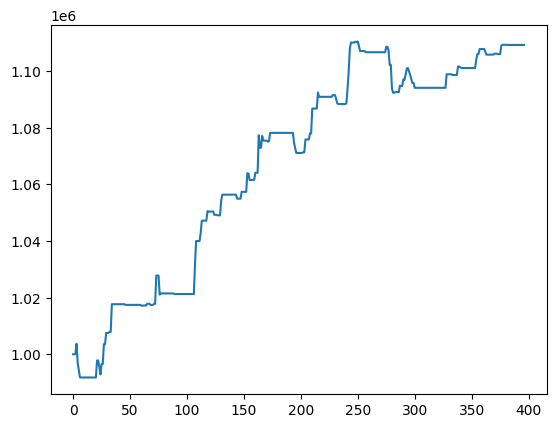

In [102]:
final_equity["equity"].plot()

In [103]:
risk = 0.5
final_equity_risk = backtest_multi_asset(all_trades, df_minutes, risk_pct=risk)

<Axes: >

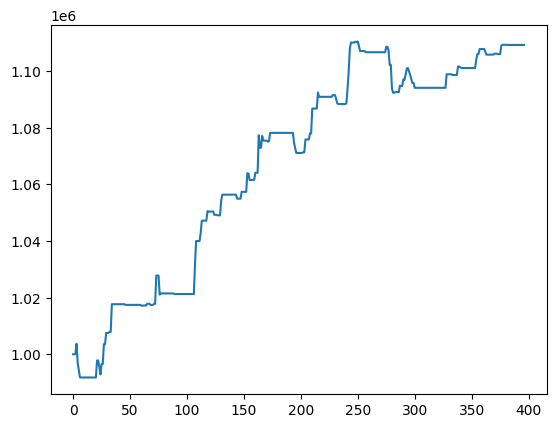

In [104]:
final_equity_risk["equity"].plot()

In [105]:
def compute_metrics(equity_curve, periods_per_year=252*4):
    """
    equity_curve: DataFrame con columnas:
        datetime, equity
    periods_per_year: frecuencia anualizada (4h → 252*6 = 1512, 
                      pero si usas 4 timestamps por día → 252*4 = 1008)
    """

    eq = equity_curve["equity"].values
    returns = np.diff(eq) / eq[:-1]

    # -----------------------------
    # 1) Max Drawdown
    # -----------------------------
    running_max = np.maximum.accumulate(eq)
    dd = (eq - running_max) / running_max
    max_dd = dd.min()

    # -----------------------------
    # 2) Sharpe Ratio
    # -----------------------------
    sharpe = np.sqrt(periods_per_year) * returns.mean() / returns.std(ddof=1)

    # -----------------------------
    # 3) Sortino Ratio
    # -----------------------------
    downside = returns[returns < 0]
    if len(downside) > 0:
        sortino = np.sqrt(periods_per_year) * returns.mean() / downside.std(ddof=1)
    else:
        sortino = np.nan

    # -----------------------------
    # 4) CAGR (para MAR y Calmar)
    # -----------------------------
    total_return = eq[-1] / eq[0] - 1
    n_years = (equity_curve["datetime"].iloc[-1] - equity_curve["datetime"].iloc[0]).days / 365
    cagr = (eq[-1] / eq[0])**(1 / n_years) - 1 if n_years > 0 else np.nan

    # -----------------------------
    # 5) MAR Ratio
    # -----------------------------
    mar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # -----------------------------
    # 6) Calmar Ratio
    # -----------------------------
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Max Drawdown": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MAR": mar,
        "Calmar": calmar
    }


In [106]:
compute_metrics(final_equity)

{'CAGR': np.float64(0.7749592017438123),
 'Max Drawdown': np.float64(-0.016299598738166277),
 'Sharpe': np.float64(4.59757871091254),
 'Sortino': np.float64(4.901090391424495),
 'MAR': np.float64(47.544679730624836),
 'Calmar': np.float64(47.544679730624836)}

In [107]:
def plot_equity_and_trades(equity_curve, df_trades):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    # -------------------------
    # PANEL 1: EQUITY CURVE
    # -------------------------
    ax1.plot(equity_curve["datetime"], equity_curve["equity"], 
             color="blue", linewidth=2)
    ax1.set_title("Equity Curve")
    ax1.grid(True, alpha=0.3)

    # -------------------------
    # PANEL 2: TRADES
    # -------------------------
    ax2.set_title("Trades (Long / Short)")
    ax2.grid(True, alpha=0.3)

    # Línea base
    ax2.plot(equity_curve["datetime"], 
             np.zeros(len(equity_curve)), 
             color="gray", alpha=0.3)

    # Entradas
    long_entries = df_trades[df_trades["type"] == "long"]
    short_entries = df_trades[df_trades["type"] == "short"]

    # ax2.scatter(long_entries["datetime_entry"], 
    ax2.scatter(long_entries["datetime_exit"], 
                np.zeros(len(long_entries)) + 0.5,
                marker="^", color="green", s=80, label="Long Entry")

    # ax2.scatter(short_entries["datetime_entry"], 
    ax2.scatter(short_entries["datetime_exit"], 
                np.zeros(len(short_entries)) - 0.5,
                marker="v", color="red", s=80, label="Short Entry")

    # Salidas
    ax2.scatter(df_trades["datetime_exit"], 
                np.zeros(len(df_trades)),
                marker="o", color="black", s=30, label="Exit")

    ax2.legend()
    plt.tight_layout()
    plt.show()


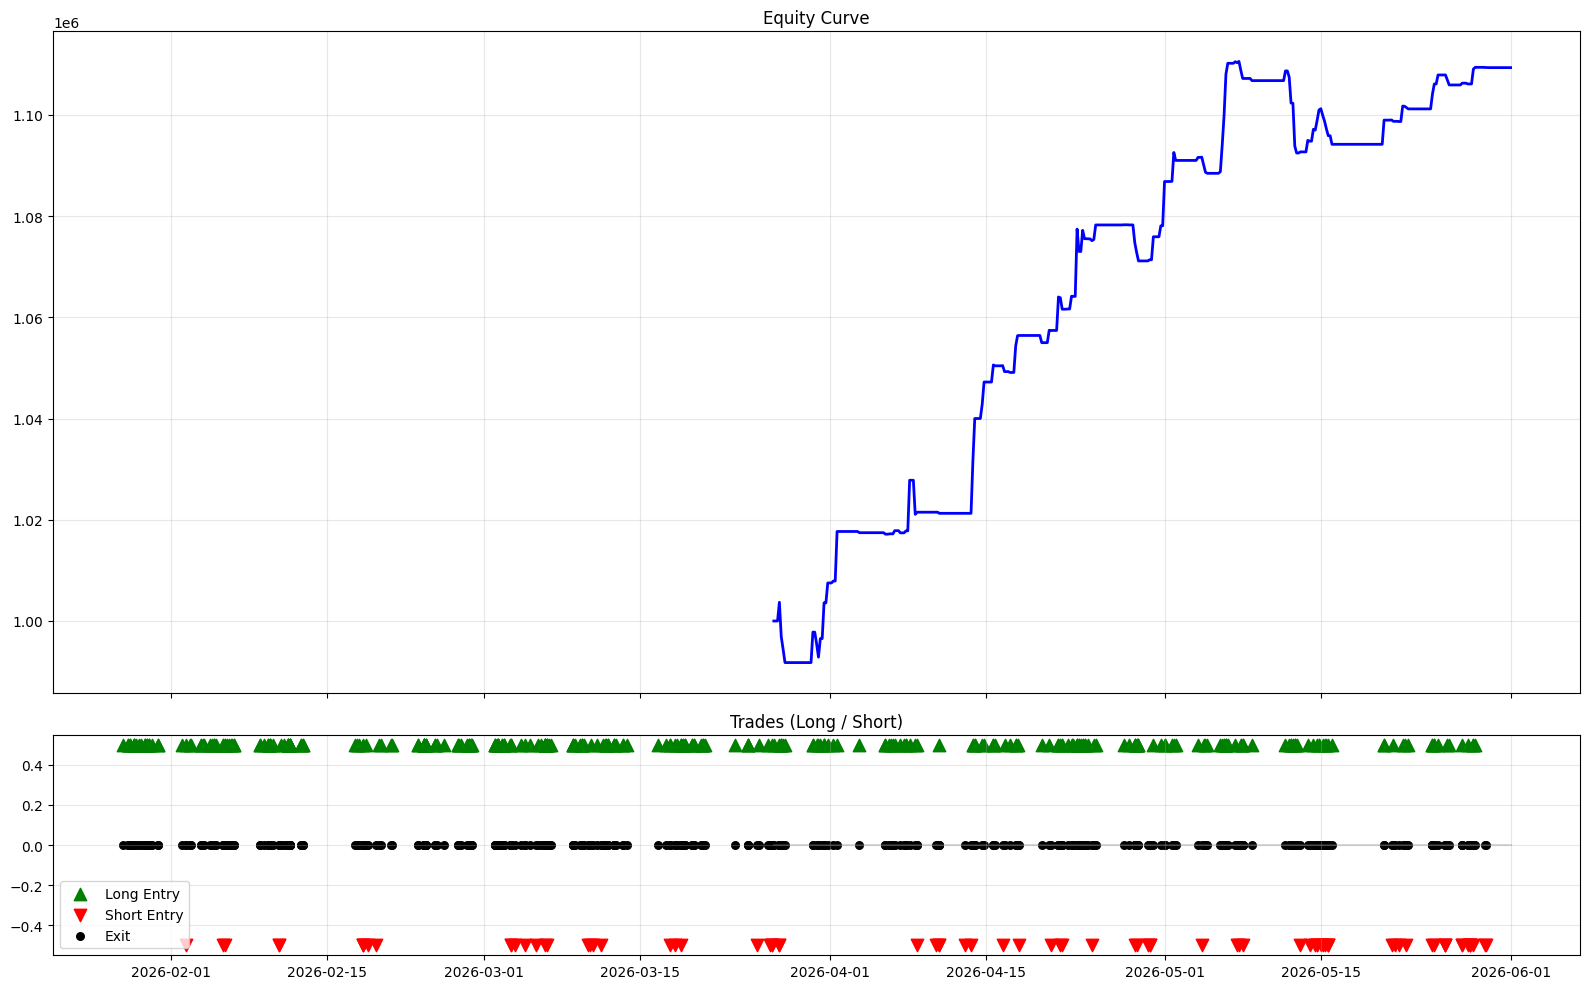

In [108]:
plot_equity_and_trades(final_equity, all_trades)